# Rapport d'analyse – Firewall IPTABLES Cloud
## Projet SISE-OPSIE 2026

**Données :** `log_export.parquet` — 11 997 652 lignes de logs IPTABLES  
**Période analysée :** Novembre 2025 – Février 2026  
**Source :** Firewall Iptables on-cloud (FW=6 supprimé à l'import)

---

---
## Partie 0 – Exploration et prétraitement des données

**Source utilisée : `log_brute.log` (format natif iptables) — bonification accordée**

Les logs bruts au format natif iptables (`log_brute.log`) ont été traités par le notebook `00_transform_raw_data.ipynb` via `KernelFirewallParser`. Ce format étant plus difficile à extraire que le CSV semi-structuré, une bonification est accordée (cf. §1.1 du sujet).

Le fichier de sortie `firewall_sample.parquet` contient les colonnes suivantes, déjà typées :

| Colonne | Type | Description |
|---|---|---|
| `timestamp` | datetime | Date et heure de l'événement |
| `src_ip` / `dst_ip` | string | IP source / destination |
| `src_port` / `dst_port` | int64 | Ports source / destination |
| `proto` | string | Protocole (`TCP`, `UDP`, …) |
| `rule` | int64 | Identifiant de règle (999 = cleanup) |
| `action` | string | `PERMIT` ou `DENY` |
| `interface_in` | string | Interface réseau d'entrée |
| `flags` | string | Flags TCP (SYN, ACK, …) |
| `ttl`, `len`, `window` | int64 | Métadonnées paquets |

> **Note :** Les cellules ci-dessous n'affichent qu'une inspection rapide du fichier produit. Pour re-générer `firewall_sample.parquet`, exécuter `notebooks/00_transform_raw_data.ipynb`.


In [1]:
import pyarrow.parquet as pq
import pyarrow as pa
import pandas as pd

FIREWALL_PARQUET = '../data/processed/firewall_sample.parquet'

pf = pq.ParquetFile(FIREWALL_PARQUET)
meta = pf.metadata
print(f"Fichier       : {FIREWALL_PARQUET}")
print(f"Lignes totales: {meta.num_rows:,}")
print(f"Row groups    : {meta.num_row_groups}")
print(f"\nSchéma :\n{pf.schema_arrow}")

# Aperçu des premières lignes
first = next(pf.iter_batches(batch_size=5))
display(pa.Table.from_batches([first]).to_pandas())


Fichier       : ../data/processed/firewall_sample.parquet
Lignes totales: 4,572,903
Row groups    : 5

Schéma :
timestamp: timestamp[us]
hostname: large_string
action: dictionary<values=string, indices=int8, ordered=0>
rule: int64
interface_in: large_string
interface_out: large_string
src_ip: large_string
dst_ip: large_string
len: int64
ttl: int64
id: int64
df: bool
proto: dictionary<values=string, indices=int8, ordered=0>
src_port: int64
dst_port: int64
window: int64
flags: large_string
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 2038


,timestamp,hostname,action,rule,interface_in,interface_out,src_ip,dst_ip,len,ttl,id,df,proto,src_port,dst_port,window,flags
0,2025-11-12 09:56:37,159.84.146.99,DENY,999,eth0,,77.90.185.64,159.84.146.99,40,236,63864,False,TCP,55366,65153,1024,SYN
1,2025-11-12 09:56:37,159.84.146.99,PERMIT,1,eth0,,47.128.20.252,159.84.146.99,60,33,13061,True,TCP,14436,443,35844,SYN
2,2025-11-12 09:56:38,159.84.146.99,PERMIT,1,eth0,,23.22.35.162,159.84.146.99,60,102,28591,True,TCP,55973,443,62727,SYN
3,2025-11-12 09:56:39,159.84.146.99,DENY,999,eth0,,79.124.60.150,159.84.146.99,40,236,20551,False,TCP,53744,56283,1024,SYN
4,2025-11-12 09:56:39,159.84.146.99,PERMIT,1,eth0,,47.128.20.252,159.84.146.99,60,32,15224,True,TCP,25404,443,35844,SYN


In [2]:
import warnings
warnings.filterwarnings('ignore')

import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
# firewall_sample.parquet : produit par 00_transform_raw_data.ipynb
# via KernelFirewallParser à partir du log natif iptables (log_brute.log) — bonification
PARQUET = Path('../data/processed/firewall_sample.parquet')

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = {'PERMIT': '#2ecc71', 'DENY': '#e74c3c'}

print('Libraries loaded.')
print(f'Source : {PARQUET}')


Libraries loaded.
Source : ..\data\processed\firewall_sample.parquet


In [3]:
# ── Load needed columns in one pass (memory-efficient) ───────────────────────
# Column mapping vs logs_parsed.parquet:
#   timestamp → date   |  src_ip → ipsrc   |  dst_ip → ipdst
#   dst_port  → portdst|  rule   → regle    |  proto / action unchanged
COLS = ['timestamp', 'src_ip', 'dst_ip', 'proto', 'dst_port', 'rule', 'action']

pf = pq.ParquetFile(PARQUET)

chunks = []
for batch in pf.iter_batches(batch_size=1_000_000, columns=COLS):
    df = batch.to_pandas()

    # ── Rename to legacy names used throughout the analysis ──────────────────
    df = df.rename(columns={
        'timestamp': 'date',
        'src_ip':    'ipsrc',
        'dst_ip':    'ipdst',
        'dst_port':  'portdst',
        'rule':      'regle',
    })

    # ── Period filter: Nov 2025 – Feb 2026 ───────────────────────────────────
    # timestamp is already datetime[us] — no parsing needed
    df = df[(df['date'] >= '2025-11-01') & (df['date'] < '2026-03-01')]

    # portdst and regle are already int64 — no conversion needed

    # ── Normalise action ─────────────────────────────────────────────────────
    df['action'] = df['action'].str.strip().str.upper()
    df['action'] = df['action'].replace({'ACCEPT': 'PERMIT', 'ALLOWED': 'PERMIT',
                                          'DROP': 'DENY', 'REJECT': 'DENY'})

    chunks.append(df)

df = pd.concat(chunks, ignore_index=True)
del chunks

# ── Protocol normalisation ────────────────────────────────────────────────────
# proto in firewall_sample.parquet is already named (TCP/UDP/…) — map just in case
PROTO_MAP = {'6': 'TCP', '17': 'UDP', '1': 'ICMP', '58': 'ICMPv6',
             'tcp': 'TCP', 'udp': 'UDP', 'icmp': 'ICMP'}
df['proto_norm'] = df['proto'].str.strip().str.upper()
df['proto_norm'] = df['proto_norm'].replace({k.upper(): v for k, v in PROTO_MAP.items()})

print(f"Rows after period filter : {len(df):,}")
print(f"Date range               : {df['date'].min()} → {df['date'].max()}")
print(f"\nProtocol distribution:\n{df['proto_norm'].value_counts().to_string()}")
print(f"\nAction distribution:\n{df['action'].value_counts().to_string()}")


Rows after period filter : 4,572,903
Date range               : 2025-11-12 09:56:37 → 2026-02-12 10:08:39

Protocol distribution:
proto_norm
TCP    4572903

Action distribution:
action
PERMIT    3747555
DENY       825348


---
## Chapitre 1 – Classement des règles les plus utilisées

Top-20 règles les plus utilisées


,Règle,Occurrences,% du total
0,1,3660700,80.05
1,999,755909,16.53
2,7,38074,0.83
3,4,32834,0.72
4,8,32827,0.72
5,6,24709,0.54
6,2,7642,0.17
7,9,7642,0.17
8,5,6656,0.15
9,11,5910,0.13


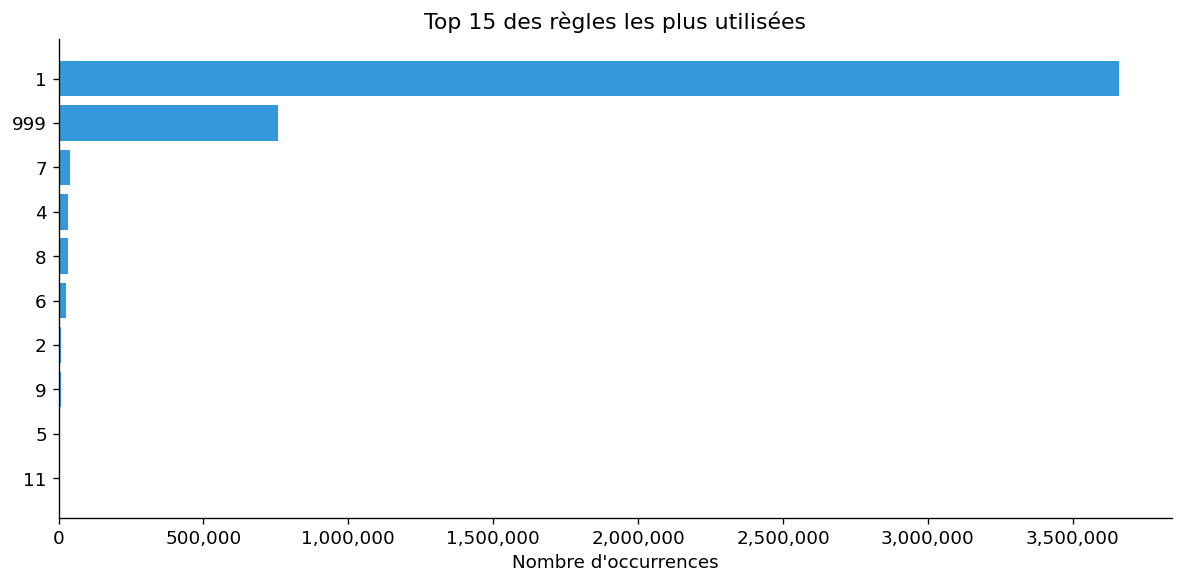

In [4]:
rule_counts = (df['regle']
               .value_counts()
               .reset_index()
               .rename(columns={'regle': 'Règle', 'count': 'Occurrences'}))
rule_counts['% du total'] = (rule_counts['Occurrences'] / len(df) * 100).round(2)
rule_counts['Règle'] = rule_counts['Règle'].astype('Int64')

print("Top-20 règles les plus utilisées")
display(rule_counts.head(20))

# ── Bar chart – top 15 ────────────────────────────────────────────────────────
top15 = rule_counts.head(15)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top15['Règle'].astype(str)[::-1], top15['Occurrences'][::-1], color='#3498db')
ax.set_xlabel('Nombre d\'occurrences')
ax.set_title('Top 15 des règles les plus utilisées')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../docs/fig_rule_ranking.png', bbox_inches='tight')
plt.show()

---
## Chapitre 2 – Distribution des protocoles

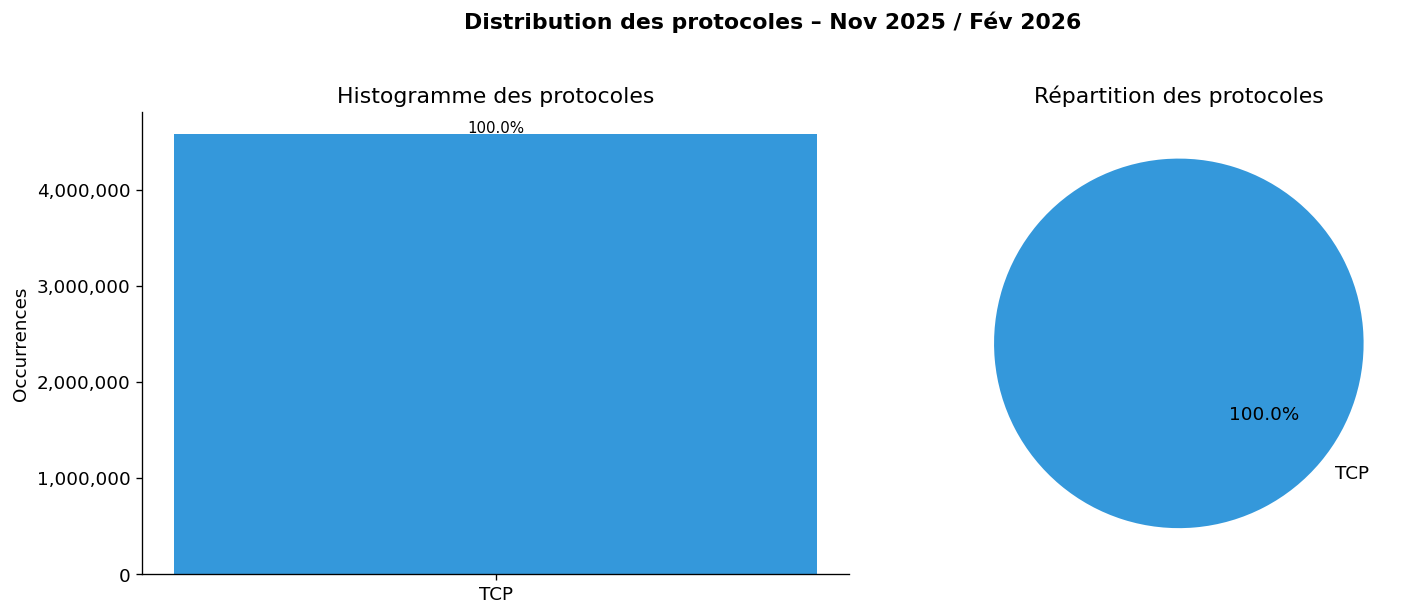

            Occurrences  % du total
proto_norm                         
TCP             4572903       100.0


In [5]:
proto_counts = df['proto_norm'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
axes[0].bar(proto_counts.index, proto_counts.values,
            color=['#3498db', '#e67e22', '#2ecc71', '#9b59b6', '#95a5a6'][:len(proto_counts)])
axes[0].set_title('Histogramme des protocoles')
axes[0].set_ylabel('Occurrences')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, v in zip(axes[0].patches, proto_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.003,
                 f'{v/len(df)*100:.1f}%', ha='center', fontsize=9)

# Pie chart
axes[1].pie(proto_counts.values, labels=proto_counts.index, autopct='%1.1f%%',
            colors=['#3498db', '#e67e22', '#2ecc71', '#9b59b6', '#95a5a6'][:len(proto_counts)],
            startangle=140)
axes[1].set_title('Répartition des protocoles')

plt.suptitle('Distribution des protocoles – Nov 2025 / Fév 2026', y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/fig_protocol_dist.png', bbox_inches='tight')
plt.show()

print(proto_counts.to_frame('Occurrences').assign(**{'% du total': (proto_counts/len(df)*100).round(2)}))

---
## Chapitre 3 – Top 10 des règles les plus utilisées avec le protocole UDP

,Règle,Occurrences UDP


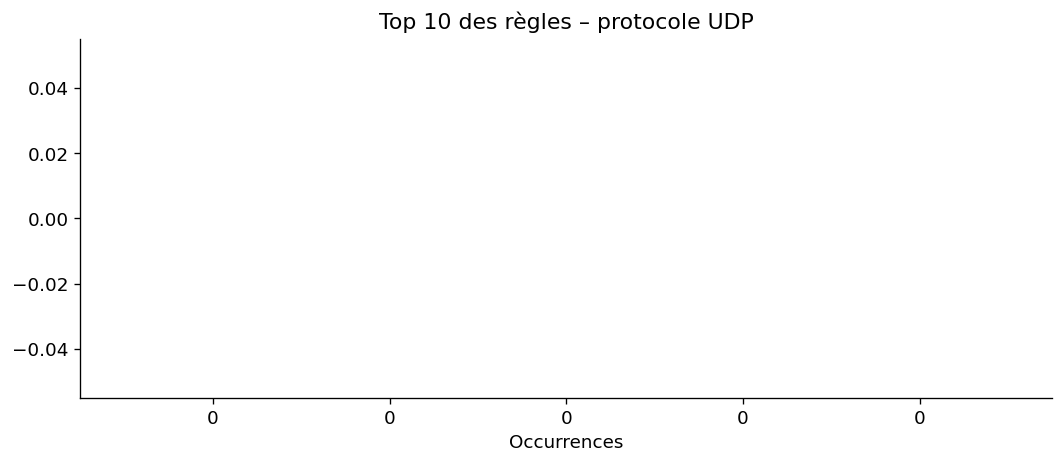

In [6]:
top10_udp = (df[df['proto_norm'] == 'UDP']['regle']
             .value_counts()
             .head(10)
             .reset_index()
             .rename(columns={'regle': 'Règle', 'count': 'Occurrences UDP'}))
top10_udp['Règle'] = top10_udp['Règle'].astype('Int64')

display(top10_udp)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(top10_udp['Règle'].astype(str)[::-1], top10_udp['Occurrences UDP'][::-1],
        color='#e67e22')
ax.set_xlabel('Occurrences')
ax.set_title('Top 10 des règles – protocole UDP')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../docs/fig_top10_udp.png', bbox_inches='tight')
plt.show()

---
## Chapitre 4 – Top 5 des règles les plus utilisées avec le protocole TCP

,Règle,Occurrences TCP
0,1,3660700
1,999,755909
2,7,38074
3,4,32834
4,8,32827


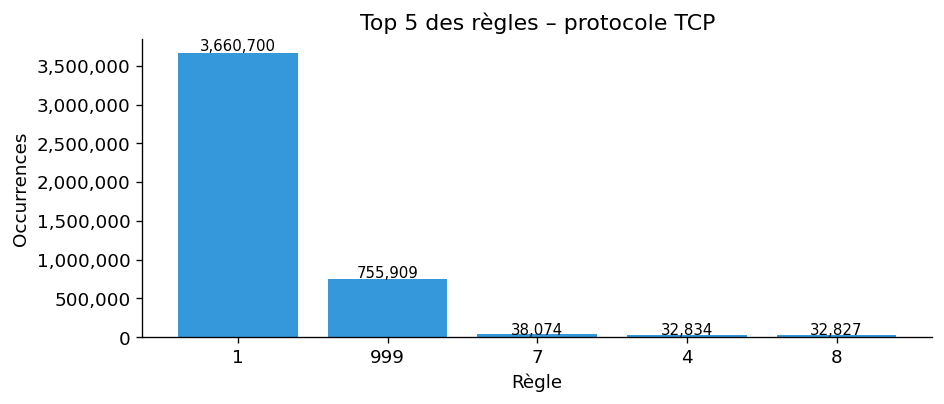

In [7]:
top5_tcp = (df[df['proto_norm'] == 'TCP']['regle']
            .value_counts()
            .head(5)
            .reset_index()
            .rename(columns={'regle': 'Règle', 'count': 'Occurrences TCP'}))
top5_tcp['Règle'] = top5_tcp['Règle'].astype('Int64')

display(top5_tcp)

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.bar(top5_tcp['Règle'].astype(str), top5_tcp['Occurrences TCP'], color='#3498db')
ax.set_xlabel('Règle')
ax.set_ylabel('Occurrences')
ax.set_title('Top 5 des règles – protocole TCP')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f'{int(bar.get_height()):,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../docs/fig_top5_tcp.png', bbox_inches='tight')
plt.show()

---
## Chapitre 5 – Rapprochement règles / ports de destination / actions (TCP uniquement)

Rapprochement règle × port destination × action (TCP) — Top 30


,regle,portdst,DENY,PERMIT,Total
1,1,443,0.0,3621944.0,3621944.0
0,1,80,0.0,38756.0,38756.0
9,7,23,38074.0,0.0,38074.0
3,4,22,0.0,32834.0,32834.0
10,8,22,0.0,32827.0,32827.0
7,6,445,20301.0,0.0,20301.0
11,9,3306,0.0,7642.0,7642.0
2,2,3306,0.0,7642.0,7642.0
8079,999,8080,7129.0,0.0,7129.0
5,5,21,6076.0,0.0,6076.0


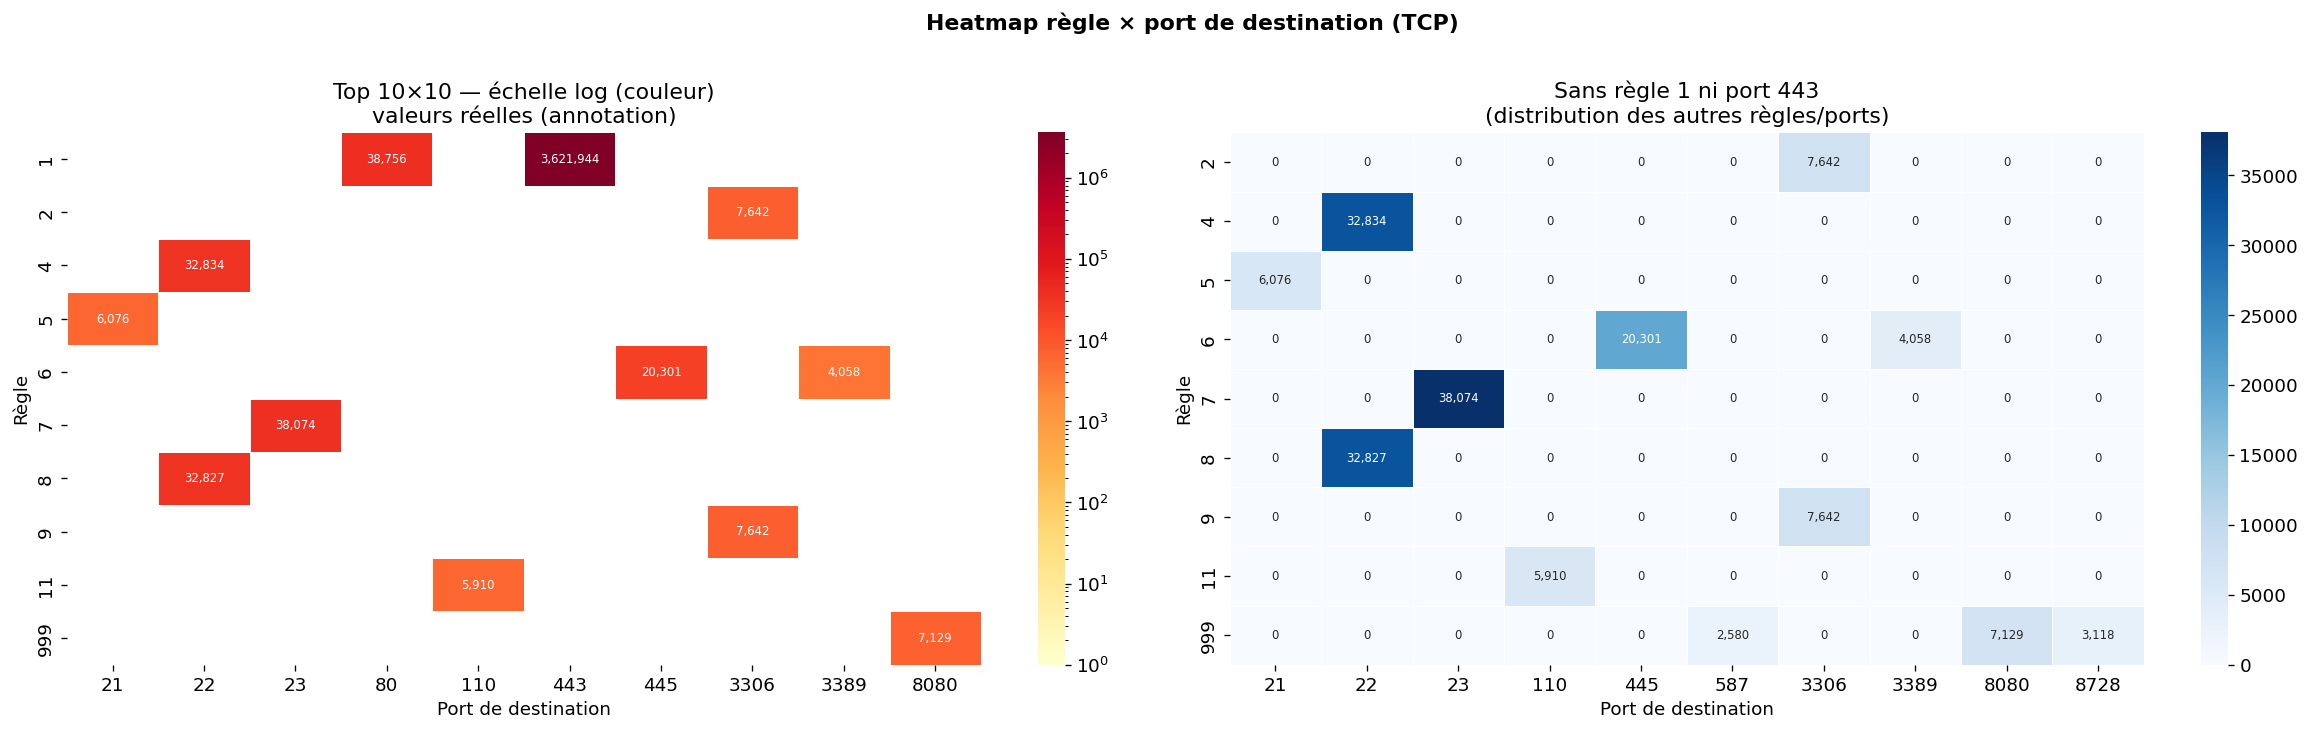

In [8]:
from matplotlib.colors import LogNorm

tcp_df = df[df['proto_norm'] == 'TCP'].copy()

rule_port_action = (tcp_df
                    .groupby(['regle', 'portdst', 'action'])
                    .size()
                    .reset_index(name='count')
                    .sort_values('count', ascending=False))

pivot = (rule_port_action
         .pivot_table(index=['regle', 'portdst'], columns='action',
                      values='count', fill_value=0)
         .reset_index())
pivot.columns.name = None
pivot['Total'] = pivot.get('PERMIT', 0) + pivot.get('DENY', 0)
pivot = pivot.sort_values('Total', ascending=False)
pivot['regle']  = pivot['regle'].astype('Int64')
pivot['portdst'] = pivot['portdst'].astype('Int64')

print("Rapprochement règle × port destination × action (TCP) — Top 30")
display(pivot.head(30))

# ── Helper to build heat_data ─────────────────────────────────────────────────
def make_heat(df_in, n_rules=10, n_ports=10):
    top_r = df_in.groupby('regle').size().nlargest(n_rules).index
    top_p = df_in.groupby('portdst').size().nlargest(n_ports).index
    return (df_in[df_in['regle'].isin(top_r) & df_in['portdst'].isin(top_p)]
            .groupby(['regle', 'portdst'])
            .size()
            .unstack(fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# ── Plot 1: log-scale colour (all top 10×10) ──────────────────────────────────
heat_all = make_heat(tcp_df)
# Annotations show real counts; colour uses log scale to reveal structure
log_norm = LogNorm(vmin=max(heat_all.values.min(), 1), vmax=heat_all.values.max())
sns.heatmap(heat_all.astype(int), annot=True, fmt=',d', cmap='YlOrRd',
            norm=log_norm, linewidths=0.5, ax=axes[0], annot_kws={'size': 7})
axes[0].set_title('Top 10×10 — échelle log (couleur)\nvaleurs réelles (annotation)')
axes[0].set_xlabel('Port de destination')
axes[0].set_ylabel('Règle')

# ── Plot 2: exclude dominant rule 1 / port 443 ───────────────────────────────
dominant_rule = pivot['regle'].iloc[0]   # rule with most traffic
dominant_port = 443                       # port 443 clearly dominant
tcp_other = tcp_df[~((tcp_df['regle'] == dominant_rule) | (tcp_df['portdst'] == dominant_port))]
heat_other = make_heat(tcp_other)
sns.heatmap(heat_other.astype(int), annot=True, fmt=',d', cmap='Blues',
            linewidths=0.5, ax=axes[1], annot_kws={'size': 7})
axes[1].set_title(f'Sans règle {int(dominant_rule)} ni port {dominant_port}\n(distribution des autres règles/ports)')
axes[1].set_xlabel('Port de destination')
axes[1].set_ylabel('Règle')

plt.suptitle('Heatmap règle × port de destination (TCP)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../docs/fig_rule_port_heatmap.png', bbox_inches='tight')
plt.show()


---
## Chapitre 6 – Graphiques complémentaires

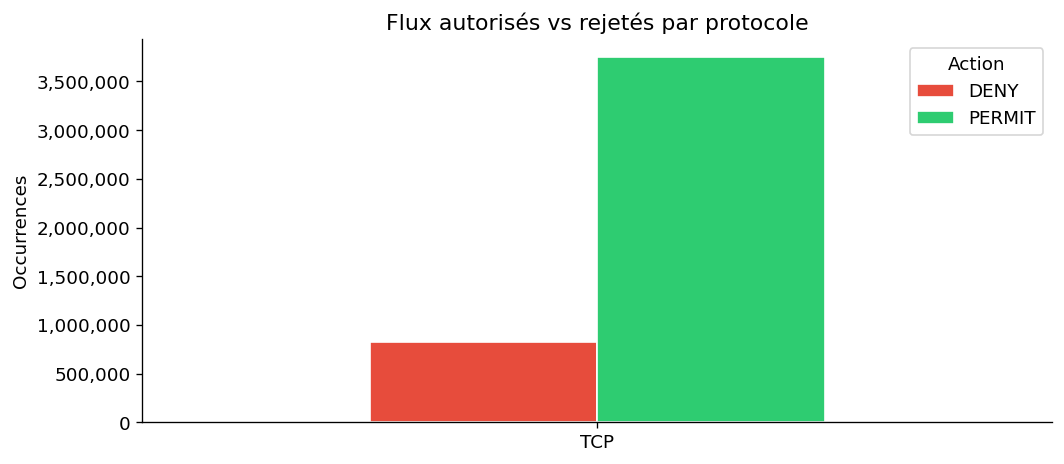

In [9]:
# ── 6.1  Flux PERMIT / DENY par protocole ────────────────────────────────────
flow = (df.groupby(['proto_norm', 'action'])
          .size()
          .reset_index(name='count')
          .pivot(index='proto_norm', columns='action', values='count')
          .fillna(0))

fig, ax = plt.subplots(figsize=(9, 4))
flow.plot(kind='bar', ax=ax,
          color=[PALETTE.get(c, '#95a5a6') for c in flow.columns],
          edgecolor='white')
ax.set_title('Flux autorisés vs rejetés par protocole')
ax.set_xlabel('')
ax.set_ylabel('Occurrences')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Action')
plt.tight_layout()
plt.savefig('../docs/fig_permit_deny_proto.png', bbox_inches='tight')
plt.show()

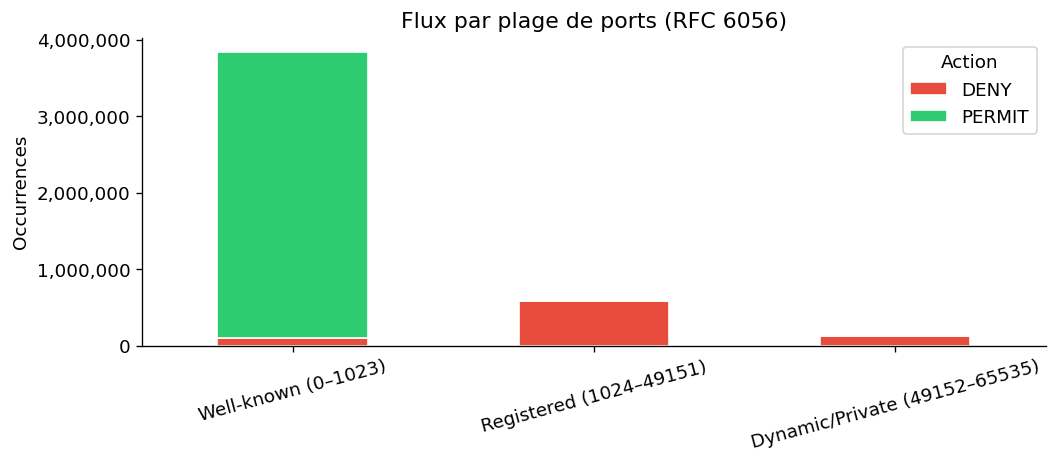

In [10]:
# ── 6.2  Répartition par plage de ports (RFC 6056) ───────────────────────────
bins   = [-1, 1023, 49151, 65535]
labels = ['Well-known (0–1023)', 'Registered (1024–49151)', 'Dynamic/Private (49152–65535)']
df['port_range'] = pd.cut(df['portdst'], bins=bins, labels=labels)

range_action = (df.groupby(['port_range', 'action'])
                  .size()
                  .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(9, 4))
range_action.plot(kind='bar', ax=ax, stacked=True,
                  color=[PALETTE.get(c, '#95a5a6') for c in range_action.columns],
                  edgecolor='white')
ax.set_title('Flux par plage de ports (RFC 6056)')
ax.set_xlabel('')
ax.set_ylabel('Occurrences')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Action')
plt.tight_layout()
plt.savefig('../docs/fig_port_ranges.png', bbox_inches='tight')
plt.show()

,IP Source,Occurrences
0,3.224.220.101,773605
1,23.22.35.162,762887
2,52.70.240.171,687748
3,51.79.181.158,68722
4,103.89.91.86,61109


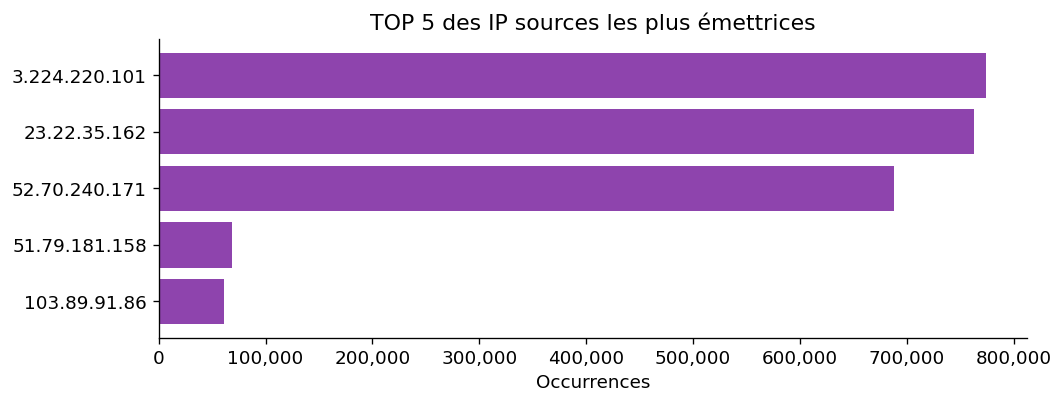

In [11]:
# ── 6.3  TOP 5 IP sources les plus émettrices ────────────────────────────────
top5_ip = (df.groupby('ipsrc')
             .size()
             .nlargest(5)
             .reset_index(name='Occurrences')
             .rename(columns={'ipsrc': 'IP Source'}))
display(top5_ip)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.barh(top5_ip['IP Source'][::-1], top5_ip['Occurrences'][::-1], color='#8e44ad')
ax.set_xlabel('Occurrences')
ax.set_title('TOP 5 des IP sources les plus émettrices')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../docs/fig_top5_ips.png', bbox_inches='tight')
plt.show()

,Port (<1024),Occurrences PERMIT
0,443,3621944
1,22,65661
2,80,38756
3,110,5910


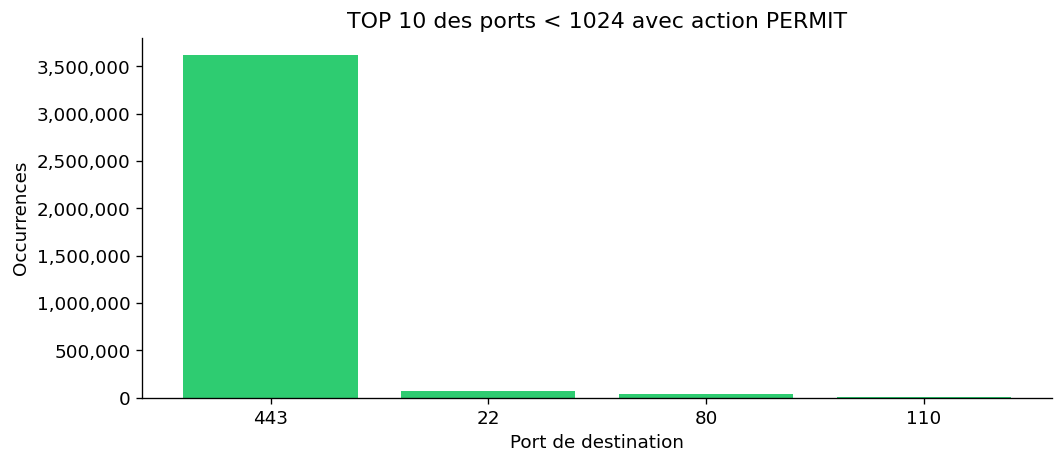

In [12]:
# ── 6.4  TOP 10 ports < 1024 autorisés (PERMIT) ──────────────────────────────
top10_permitted_ports = (df[(df['portdst'] < 1024) & (df['action'] == 'PERMIT')]['portdst']
                         .value_counts()
                         .head(10)
                         .reset_index()
                         .rename(columns={'portdst': 'Port (<1024)', 'count': 'Occurrences PERMIT'}))
top10_permitted_ports['Port (<1024)'] = top10_permitted_ports['Port (<1024)'].astype('Int64')
display(top10_permitted_ports)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(top10_permitted_ports['Port (<1024)'].astype(str),
       top10_permitted_ports['Occurrences PERMIT'], color='#2ecc71')
ax.set_title('TOP 10 des ports < 1024 avec action PERMIT')
ax.set_xlabel('Port de destination')
ax.set_ylabel('Occurrences')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../docs/fig_top10_permitted_ports.png', bbox_inches='tight')
plt.show()

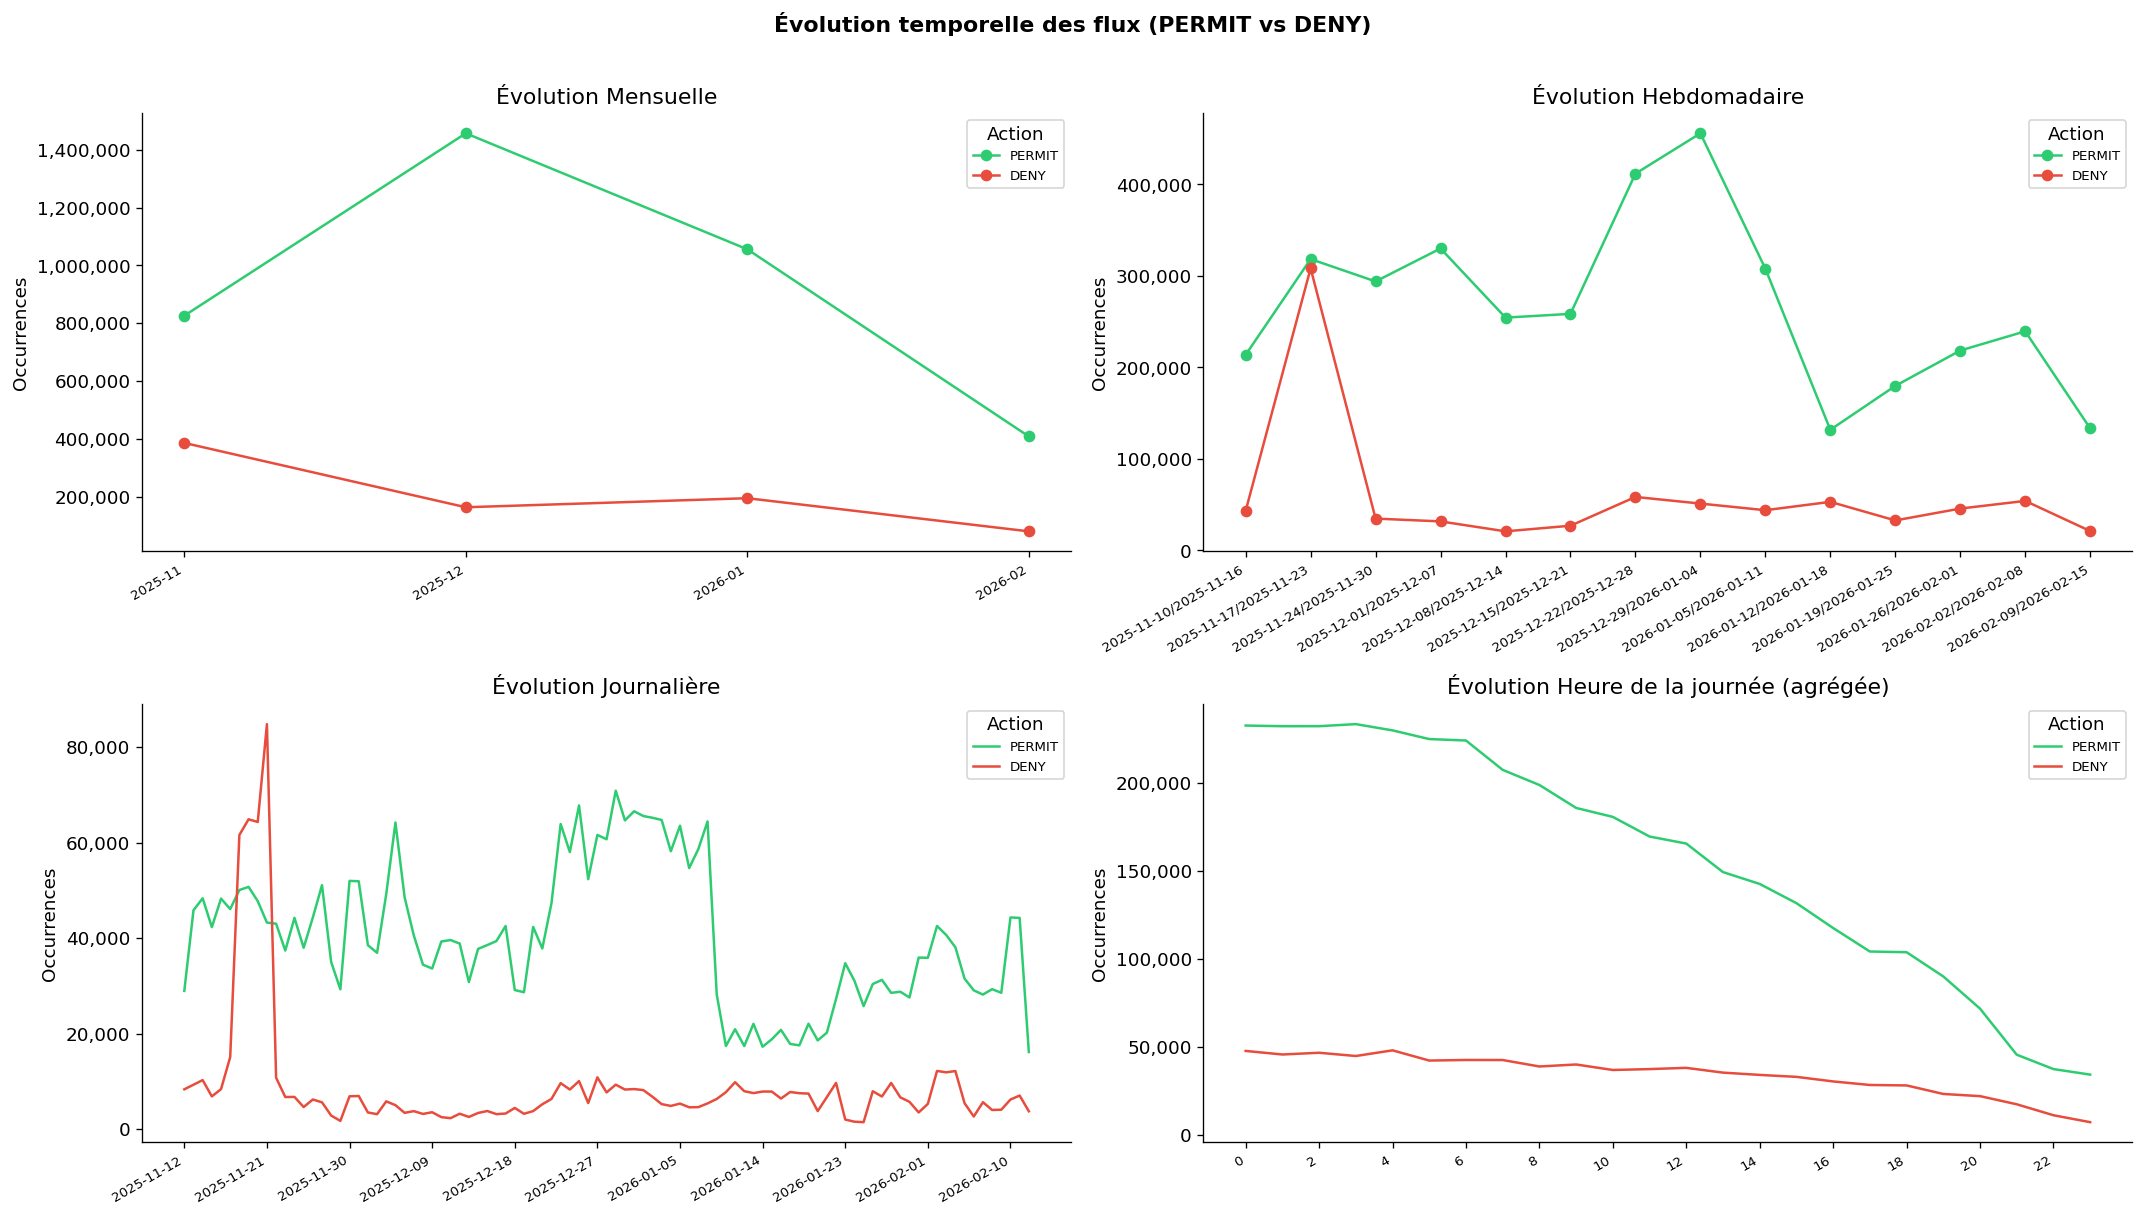

In [13]:
# ── 6.5  Évolution temporelle : mensuelle / hebdomadaire / journalière / horaire
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

resolutions = [
    ('Mensuelle',      df['date'].dt.to_period('M').astype(str)),
    ('Hebdomadaire',   df['date'].dt.to_period('W').astype(str)),
    ('Journalière',    df['date'].dt.date.astype(str)),
    ('Heure de la journée (agrégée)', df['date'].dt.hour),
]

for ax, (title, grouper) in zip(axes, resolutions):
    ts = (df.groupby([grouper, 'action'])
            .size()
            .unstack(fill_value=0)
            .sort_index())
    for action, color in PALETTE.items():
        if action in ts.columns:
            ax.plot(range(len(ts)), ts[action].values,
                    label=action, color=color, linewidth=1.5,
                    marker=('o' if len(ts) <= 20 else None))
    # X-axis ticks: show a manageable number of labels
    n = len(ts)
    step = max(1, n // 10)
    ax.set_xticks(range(0, n, step))
    ax.set_xticklabels(ts.index[::step], rotation=30, ha='right', fontsize=8)
    ax.set_title(f'Évolution {title}')
    ax.set_ylabel('Occurrences')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(title='Action', fontsize=8)

plt.suptitle('Évolution temporelle des flux (PERMIT vs DENY)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../docs/fig_temporal_evolution.png', bbox_inches='tight')
plt.show()


Nombre total d'événements le 2025-11-21 : 128,099
action
DENY      84832
PERMIT    43267


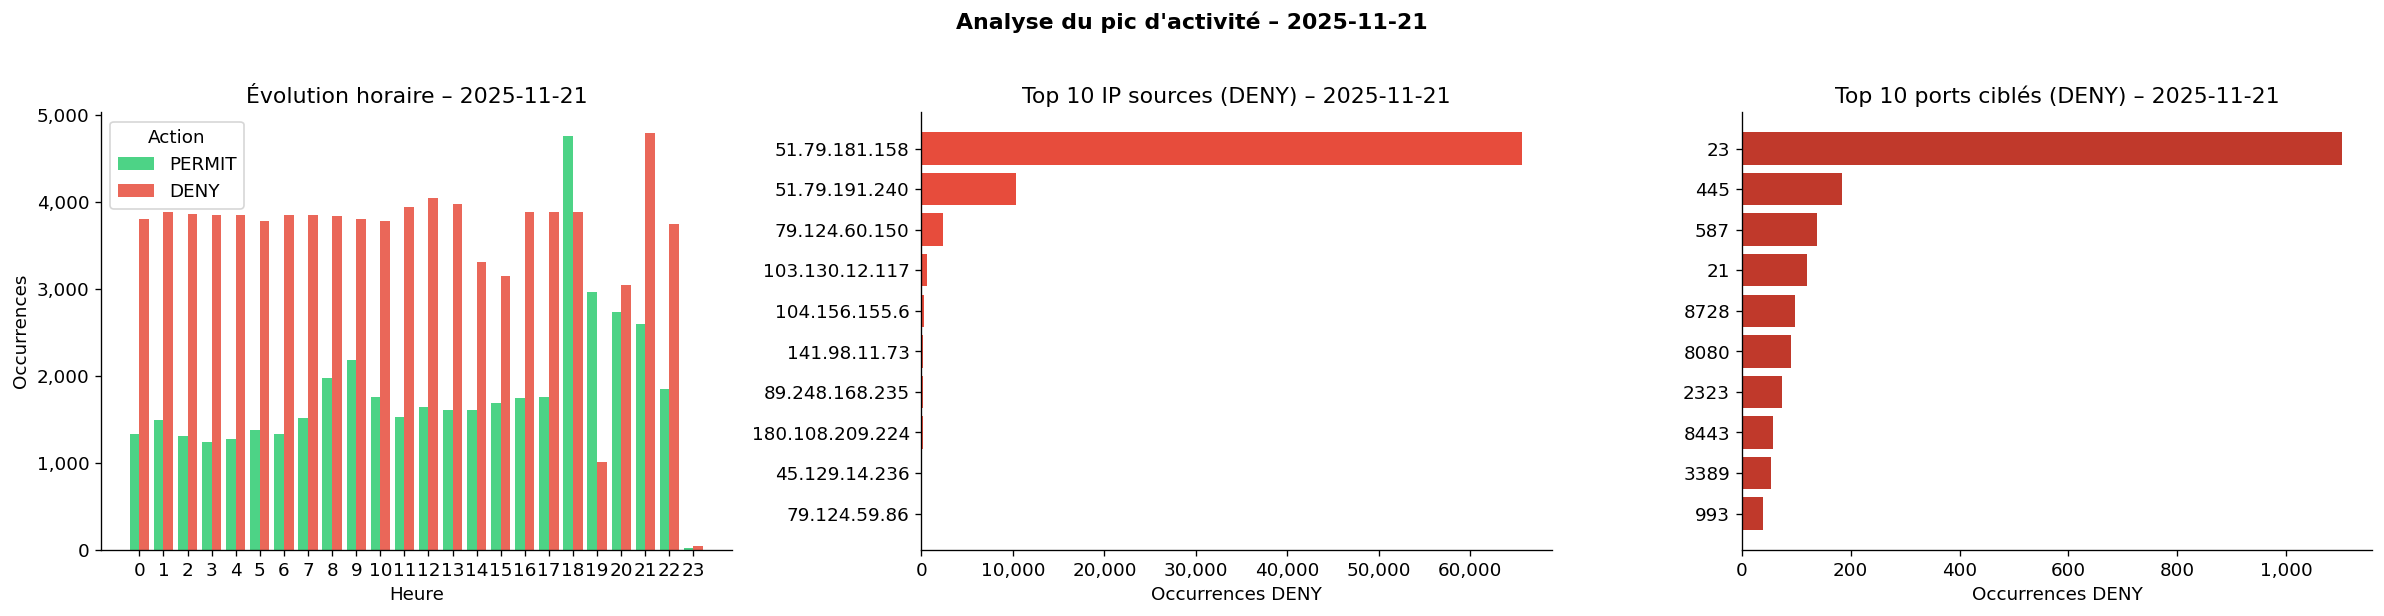

In [14]:
# ── 6.6  Zoom sur le pic du 2025-11-21 ──────────────────────────────────────
SPIKE_DATE = '2025-11-21'
day = df[df['date'].dt.date.astype(str) == SPIKE_DATE].copy()
day['hour'] = day['date'].dt.hour

print(f"Nombre total d'événements le {SPIKE_DATE} : {len(day):,}")
print(day['action'].value_counts().to_string())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ── Évolution horaire PERMIT / DENY ─────────────────────────────────────────
hourly = (day.groupby(['hour', 'action'])
             .size()
             .unstack(fill_value=0)
             .reindex(range(24), fill_value=0))
for action, color in PALETTE.items():
    if action in hourly.columns:
        axes[0].bar(hourly.index - (0.2 if action == 'PERMIT' else -0.2),
                    hourly[action], width=0.4, label=action, color=color, alpha=0.85)
axes[0].set_title(f'Évolution horaire – {SPIKE_DATE}')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('Occurrences')
axes[0].set_xticks(range(24))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend(title='Action')

# ── Top 10 IP sources dans les DENY ce jour-là ───────────────────────────────
top_deny_ips = (day[day['action'] == 'DENY']['ipsrc']
                .value_counts()
                .head(10)
                .reset_index()
                .rename(columns={'ipsrc': 'IP Source', 'count': 'DENY'}))
axes[1].barh(top_deny_ips['IP Source'][::-1], top_deny_ips['DENY'][::-1], color='#e74c3c')
axes[1].set_title(f'Top 10 IP sources (DENY) – {SPIKE_DATE}')
axes[1].set_xlabel('Occurrences DENY')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── Top 10 ports ciblés dans les DENY ce jour-là ────────────────────────────
top_deny_ports = (day[day['action'] == 'DENY']['portdst']
                  .value_counts()
                  .head(10)
                  .reset_index()
                  .rename(columns={'portdst': 'Port', 'count': 'DENY'}))
top_deny_ports['Port'] = top_deny_ports['Port'].astype('Int64')
axes[2].barh(top_deny_ports['Port'].astype(str)[::-1], top_deny_ports['DENY'][::-1], color='#c0392b')
axes[2].set_title(f'Top 10 ports ciblés (DENY) – {SPIKE_DATE}')
axes[2].set_xlabel('Occurrences DENY')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle(f'Analyse du pic d\'activité – {SPIKE_DATE}', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/fig_spike_20251121.png', bbox_inches='tight')
plt.show()


### Analyse du pic du 21 novembre 2025

Le 21 novembre 2025 présente **128 099 événements**, dont **84 832 DENY** (66 %) contre 43 267 PERMIT — soit le jour le plus chargé en rejets de toute la période analysée.

**Évolution horaire :** le trafic DENY est élevé et constant toute la journée (~3 500–4 000 événements/heure), avec un pic notable entre **22h et 23h** (~4 800 événements). Il ne s'agit donc pas d'un burst ponctuel mais d'une **attaque soutenue sur 24 heures**.

**Attaquant principal :** l'IP `51.79.181.158` génère à elle seule **~65 000 DENY**, soit plus de 75 % du volume de rejets de la journée. Il s'agit d'une source unique et très agressive.

**Ports ciblés :**

| Port | Service | Interprétation |
|------|---------|----------------|
| **23** | Telnet | Cible principale — brute-force ou scan de routeurs/IoT |
| **445** | SMB | Tentatives d'exploitation Windows (type EternalBlue) |
| **587** | SMTP submission | Tentatives de relai mail / spam |
| **21** | FTP | Brute-force FTP |
| **8728** | RouterOS API | Ciblage d'équipements MikroTik |
| **8080** | HTTP alternatif | Scan de proxies ou interfaces web |

**Conclusion :** le profil (port 23, 8728, source unique et persistante) est caractéristique d'une **campagne de scan/brute-force IoT et routeurs**, possiblement liée à un botnet cherchant à recruter de nouveaux équipements. L'IP `51.79.181.158` mériterait d'être bloquée en entrée et vérifiée sur des bases de réputation (AbuseIPDB, Shodan).


In [15]:
# ── 6.6  IPs externes (hors plan d'adressage Université 159.84.x.x) ──────────
external_src = df[~df['ipsrc'].str.startswith('159.84.', na=False)]
external_dst = df[~df['ipdst'].str.startswith('159.84.', na=False)]

print(f"Flux depuis IP sources externes : {len(external_src):,}")
print(f"Flux vers IP destinations externes : {len(external_dst):,}")
print("\nTop 10 IP sources externes :")
display(external_src['ipsrc'].value_counts().head(10)
        .reset_index().rename(columns={'ipsrc': 'IP Source', 'count': 'Occurrences'}))

Flux depuis IP sources externes : 4,570,893
Flux vers IP destinations externes : 0

Top 10 IP sources externes :


,IP Source,Occurrences
0,3.224.220.101,773605
1,23.22.35.162,762887
2,52.70.240.171,687748
3,51.79.181.158,68722
4,103.89.91.86,61109
5,103.151.123.241,60630
6,103.139.44.2,49874
7,89.248.165.166,34097
8,23.230.171.181,31143
9,77.90.185.64,27115


---
## Export PDF

Pour générer le rapport PDF depuis ce notebook :

```bash
# Option 1 – PDF via LaTeX (nécessite une installation LaTeX)
jupyter nbconvert --to pdf analysis_report.ipynb --output analysis_report.pdf

# Option 2 – HTML puis imprimer en PDF depuis le navigateur
jupyter nbconvert --to html analysis_report.ipynb --output analysis_report.html

# Option 3 – WebPDF (sans LaTeX, nécessite chromium)
jupyter nbconvert --to webpdf analysis_report.ipynb --output analysis_report.pdf
```